Siamo molto bravi a programmare


In [2]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys
from sklearn.preprocessing import LabelEncoder

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from pandas.plotting import scatter_matrix

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

Poi abbiamo importato

In [3]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
 )

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

merged = merged.drop_duplicates(subset=['track_id'], keep='first')

merged["artist_active_start_year"] = (pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce").astype("Int64"))
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]

merged["track_presumed_flatness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

artist_age = merged["track_year"] - merged["artist_birth_year"]
missing_age = merged["track_year"].isna() | merged["artist_birth_year"].isna()
merged["track_artist_age"] = artist_age.where(~missing_age, pd.NA)

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)

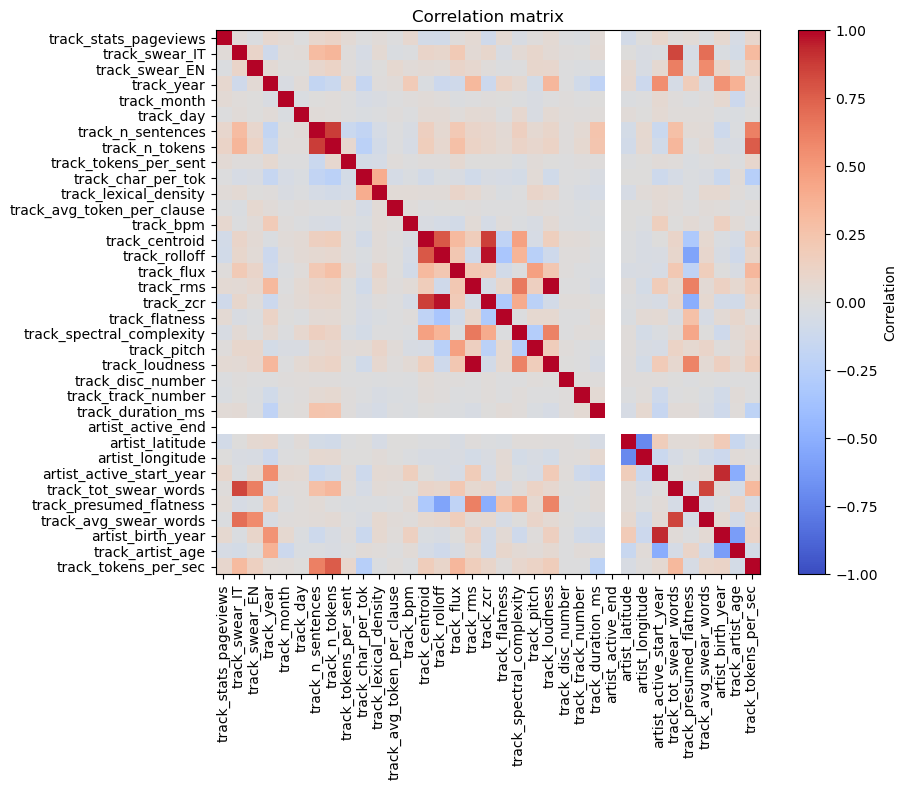

Strongly correlated pairs:
track_rms                  track_loudness               0.995550
track_rolloff              track_zcr                    0.969144
artist_active_start_year   artist_birth_year            0.927034
track_n_sentences          track_n_tokens               0.867862
track_centroid             track_zcr                    0.864460
track_tot_swear_words      track_avg_swear_words        0.850638
track_swear_IT             track_tot_swear_words        0.841941
track_centroid             track_rolloff                0.775799
track_n_tokens             track_tokens_per_sec         0.760865
track_swear_IT             track_avg_swear_words        0.692821
track_rms                  track_spectral_complexity    0.643962
track_swear_EN             track_tot_swear_words        0.624154
track_rms                  track_presumed_flatness      0.616247
track_n_sentences          track_tokens_per_sec         0.610060
track_spectral_complexity  track_loudness               0.60852

In [4]:
# Correlation heatmap for numeric columns
corr = merged.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = corr_pairs.stack().sort_values(ascending=False)
print("Strongly correlated pairs:")
print(strong_pairs[strong_pairs.abs() > 0.5])

Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

In [5]:
# Discretize numeric variables into categorical bins
bpm = pd.to_numeric(merged["track_bpm"], errors="coerce")
pop = pd.to_numeric(merged["track_popularity"], errors="coerce")
dur = pd.to_numeric(merged["track_duration_ms"], errors="coerce")
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
swear_total = swear_it.add(swear_en, fill_value=0)

# Swear density = swear words per minute
duration_min = dur / 60000
swear_density = swear_total / duration_min
swear_density = swear_density.replace([np.inf, -np.inf], np.nan)

encoded = pd.get_dummies([])

encoded["bpm"] = pd.cut(
    bpm,
    bins=[-np.inf, 90, 120, np.inf],
    labels=["Slow", "Medium", "Fast"]
 )

encoded["popularity"] = pd.cut(
    pop,
    bins=[-np.inf, 3e1, np.inf],
    labels=["Low", "High"]
 )

encoded["duration"] = pd.cut(
    dur,
    bins=[-np.inf, 180000, 300000, np.inf],
    labels=["Short", "Medium", "Long"]
 )

median_swear_density = swear_density.median(skipna=True)
encoded["swear_density"] = pd.cut(
    swear_density,
    bins=[-np.inf, median_swear_density, np.inf],
    labels=["Low", "High"]
 )

encoded["lexical_density"] = pd.cut(
    pd.to_numeric(merged["track_lexical_density"], errors="coerce"),
    bins=[-np.inf, 0.5, np.inf],
    labels=["Low", "High"]
 )

 
encoded["loudness"] = pd.cut(
    pd.to_numeric(merged["track_loudness"], errors="coerce"),
    bins=[-np.inf, 27, 54, np.inf],
    labels=["Soft", "Medium", "Loud"]
 )

encoded["acuteness"] = pd.cut(
    pd.to_numeric(merged["track_centroid"], errors="coerce"),
    bins=[-np.inf, 0.15, np.inf],
    labels=["Low", "High"]
 )


C:\Users\ludol\AppData\Local\Temp\ipykernel_9268\120024897.py:14: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  encoded = pd.get_dummies([])


In [6]:
# Build transactions with explicit col_name_value labels
transactions = encoded.apply(lambda row: [f"{col}_{row[col]}" for col in encoded.columns], axis=1).tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

df["swear_high_short"] = df["swear_density_High"] & df["duration_Short"]
df["swear_low_soft"] = df["swear_density_Low"] & df["loudness_Soft"]
df["swear_low_popular"] = df["swear_density_Low"] & df["popularity_High"]
df["lexical_low_soft"] = df["lexical_density_Low"] & df["loudness_Soft"]



In [7]:
merged['artist_region']= merged.apply(lambda row: 'Marche' if (row["artist_province"] == "Ancona") & (pd.isna(row["artist_region"])) else row['artist_region'], axis=1)
merged=merged.dropna(subset=["artist_region"])
merged["artist_region"].unique()

array(['Piemonte', 'Lazio', 'Campania', 'Lombardia', 'Marche', 'Liguria',
       'Toscana', 'Veneto', 'Puglia', 'Sardegna', 'Emilia-Romagna',
       'Calabria', 'Sicilia'], dtype=object)

In [8]:
merged['artist_macro_region']= merged['artist_region'].apply(lambda x: 
    'North' if x in ['Piemonte', 'Lombardia', 'Liguria', 'Veneto'] 
    else 'Lazio' if x=='Lazio' 
    else 'Campania' if x=='Campania' 
    else 'Sardegna' if x=='Sardegna' 
    else 'South' if x in ['Puglia', 'Calabria', 'Sicilia'] 
    else 'Center' )

In [9]:
merged['artist_macro_region'].value_counts()

North       4233
Campania    1289
Lazio       1146
Center       620
South        598
Sardegna     523
Name: artist_macro_region, dtype: int64

In [11]:
ds = pd.DataFrame(dtype="object")
for col in [ 'track_duration_ms', 'track_lexical_density', 'track_tot_swear_words', 'track_avg_swear_words', 'artist_macro_region' ]:
    ds[col] = merged[col]

ds['swear_low_soft'] = df["swear_low_soft"]


c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


In [12]:

ds.dropna(inplace=True)
print(ds.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 8258 entries, 0 to 11092
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   track_duration_ms      8258 non-null   float64
 1   track_lexical_density  8258 non-null   float64
 2   track_tot_swear_words  8258 non-null   int64  
 3   track_avg_swear_words  8258 non-null   float64
 4   artist_macro_region    8258 non-null   object 
 5   swear_low_soft         8258 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 451.6+ KB
None


In [13]:
le = LabelEncoder()
num_classes = le.fit_transform(ds['artist_macro_region'])

In [14]:
ds['artist_macro_region'].value_counts()/len(ds)

North       0.503391
Campania    0.155849
Lazio       0.138775
Center      0.075079
South       0.063696
Sardegna    0.063211
Name: artist_macro_region, dtype: float64

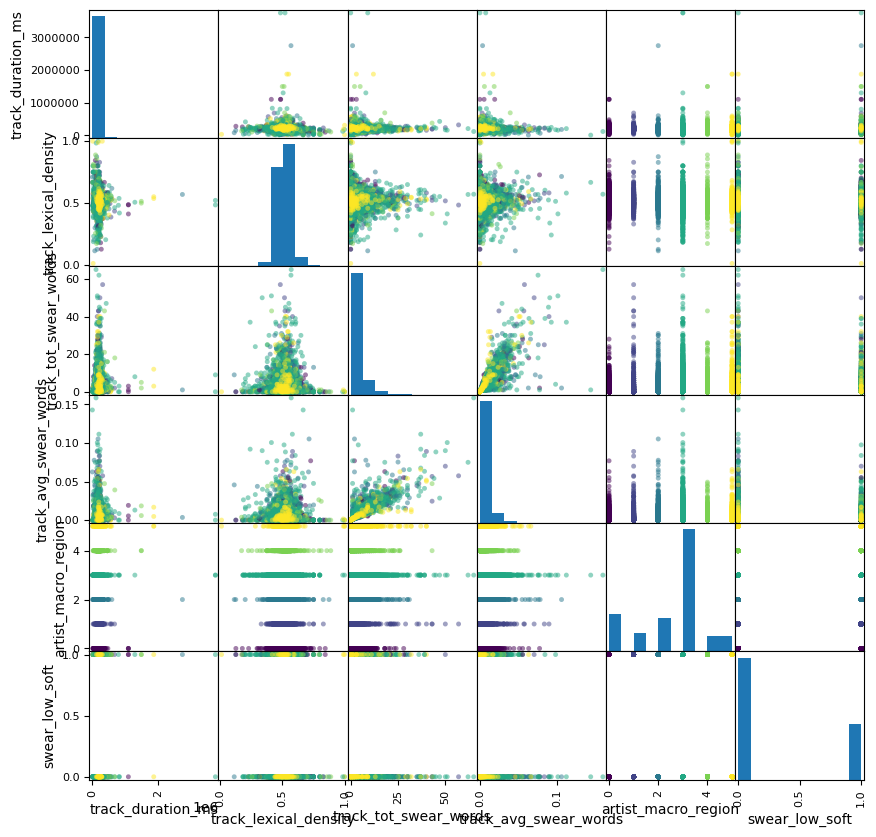

In [15]:
# Make a numeric-only copy for plotting
ds_num = ds.copy()

# Convert bools to 0/1
bool_cols = ds_num.select_dtypes(include="bool").columns
ds_num[bool_cols] = ds_num[bool_cols].astype(int)

# Convert non-numeric (object/category) to codes
for col in ds_num.columns:
    if not pd.api.types.is_numeric_dtype(ds_num[col]):
        ds_num[col] = ds_num[col].astype("category").cat.codes

# Drop any remaining NaN/Inf and align labels
ds_num = ds_num.replace([np.inf, -np.inf], np.nan).dropna()
num_classes = le.fit_transform(ds.loc[ds_num.index, "artist_macro_region"])

scatter_matrix(ds_num, figsize=(10, 10), c=num_classes, s=50)
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn import tree



In [17]:
predictors = [col for col in ds.columns if col != 'artist_macro_region']
X = ds[predictors].values
y = ds['artist_macro_region'].values

c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=13, 
                                                    stratify=y)

In [19]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=None, 
                             min_samples_split=2, min_samples_leaf=1)

In [20]:
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [21]:
for col, imp in zip(predictors, clf.feature_importances_):
    print(col, imp)
print(clf.classes_)

track_duration_ms 0.34805375620671103
track_lexical_density 0.3547675184287791
track_tot_swear_words 0.07263183617236908
track_avg_swear_words 0.21199112154501593
swear_low_soft 0.012555767647124665
['Campania' 'Center' 'Lazio' 'North' 'Sardegna' 'South']


In [22]:
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.32929782082324455
F1-score [0.20474407 0.11027569 0.17354196 0.50924025 0.08668731 0.11525424]
              precision    recall  f1-score   support

    Campania       0.20      0.21      0.20       386
      Center       0.10      0.12      0.11       186
       Lazio       0.17      0.18      0.17       344
       North       0.52      0.50      0.51      1247
    Sardegna       0.08      0.09      0.09       157
       South       0.12      0.11      0.12       158

    accuracy                           0.33      2478
   macro avg       0.20      0.20      0.20      2478
weighted avg       0.34      0.33      0.33      2478



In [23]:
clf_ran = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=2, min_samples_leaf=1,
                             criterion='entropy')

In [24]:
clf_ran.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred = clf_ran.predict(X_test)
accuracy_score(y_test, y_pred)

0.5016142050040355

In [26]:
clf = svm.SVC( )
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.5044390637610977

In [28]:
clf=DecisionTreeClassifier(criterion='gini', max_depth=3, 
                             min_samples_split=5, min_samples_leaf=2, random_state=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.4975786924939467

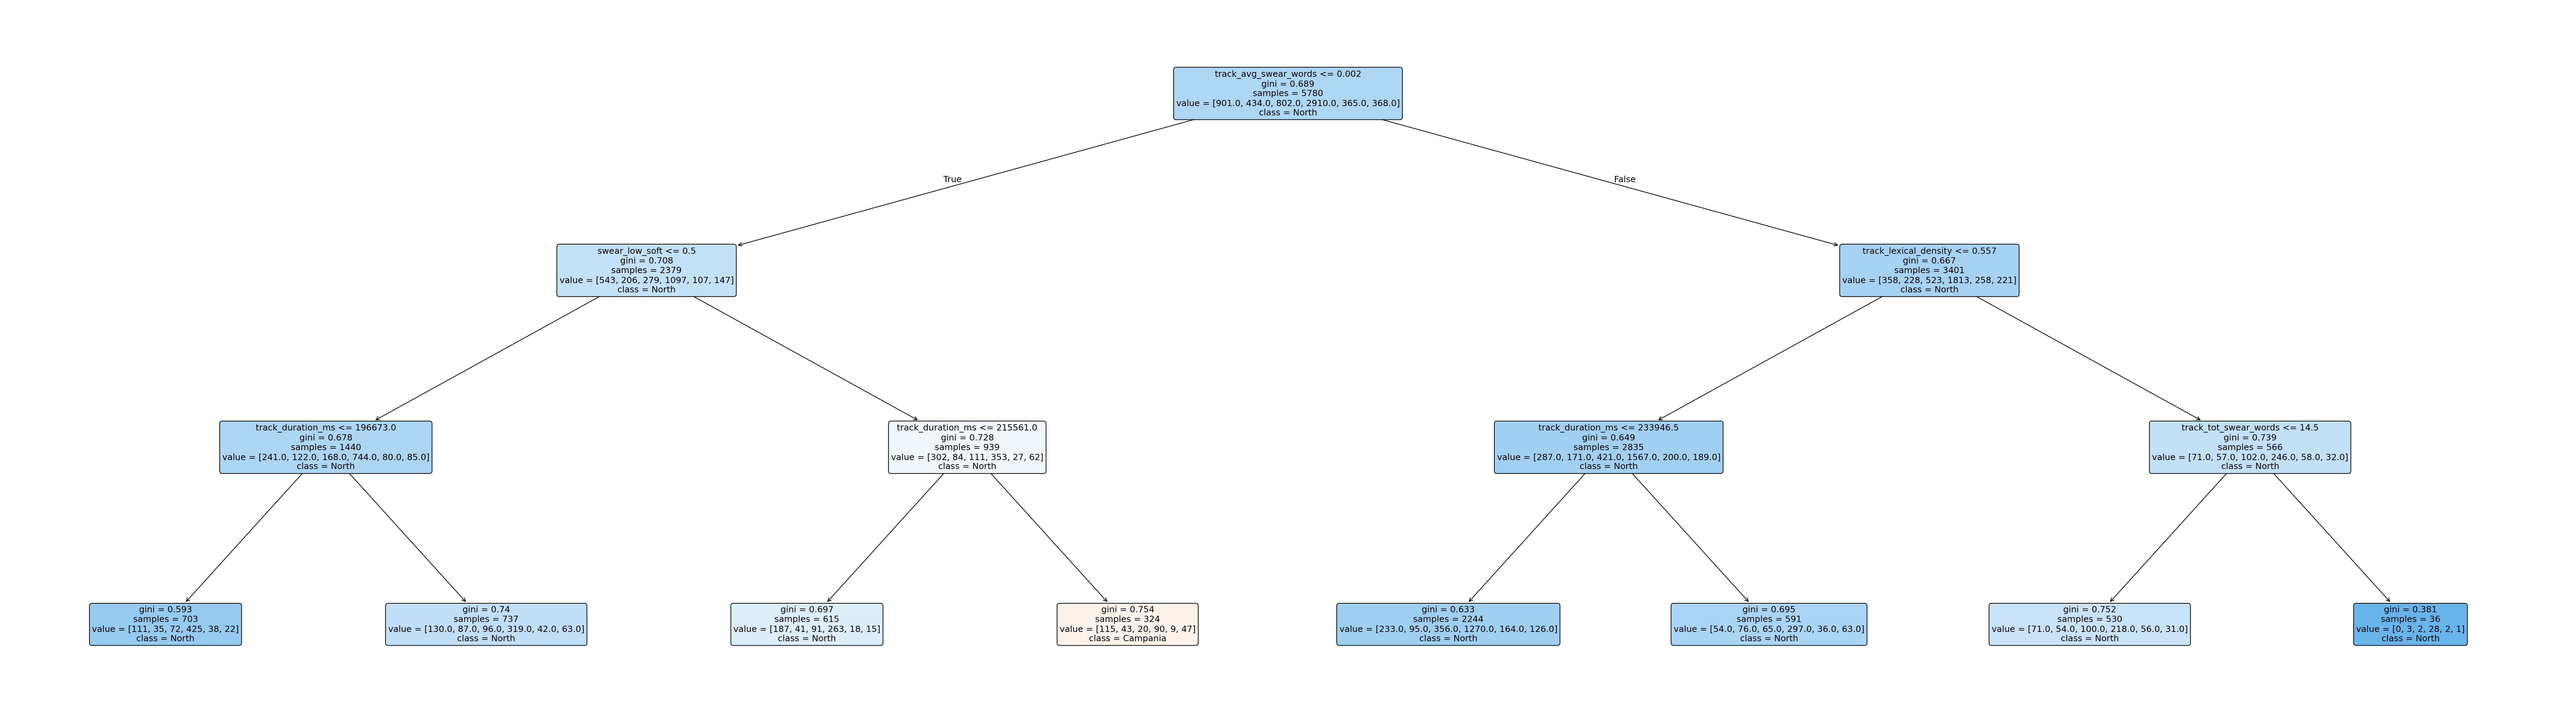

In [29]:

plt.figure(figsize=(50, 14), dpi=150)
tree.plot_tree(
    clf,
    feature_names=predictors,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=12,
 )
plt.tight_layout()
plt.show()

In [30]:
y_pred= clf_ran.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Campania       0.26      0.03      0.05       386
      Center       0.00      0.00      0.00       186
       Lazio       0.00      0.00      0.00       344
       North       0.51      0.99      0.67      1247
    Sardegna       0.00      0.00      0.00       157
       South       0.00      0.00      0.00       158

    accuracy                           0.50      2478
   macro avg       0.13      0.17      0.12      2478
weighted avg       0.29      0.50      0.34      2478



c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [31]:
confusion_matrix(y_test, y_pred)

array([[  10,    0,    0,  376,    0,    0],
       [   6,    0,    0,  180,    0,    0],
       [   4,    0,    0,  340,    0,    0],
       [  14,    0,    0, 1233,    0,    0],
       [   0,    0,    0,  157,    0,    0],
       [   5,    0,    0,  153,    0,    0]], dtype=int64)